每个预测器使用的算法相同，但在不同的训练集随机子集上进行训练

偏差相似，但是方差减小

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

X, y = make_moons(n_samples=1000, noise=0.22, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [2]:
single_tree = DecisionTreeClassifier(max_depth=4, random_state=42)

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=4, random_state=42),
    n_estimators=500,       # 基学习器数量
    max_samples=0.8,        # 每轮采样样本的比例
    bootstrap=True,         # 自助采样
    oob_score=True,         # 包外评估
    random_state=42,
    n_jobs=-1
)

single_tree.fit(X_train, y_train)
bag_clf.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,500
,max_samples,0.8
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,True
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [3]:
def print_acc(model, name):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{name:18s} | 测试准确率: {acc:.4f}")

print_acc(single_tree, "Single DecisionTree")
print_acc(bag_clf, "BaggingClassifier")
print("包外评估精度: ",bag_clf.oob_score_)

Single DecisionTree | 测试准确率: 0.9233
BaggingClassifier  | 测试准确率: 0.9400
包外评估精度:  0.9142857142857143


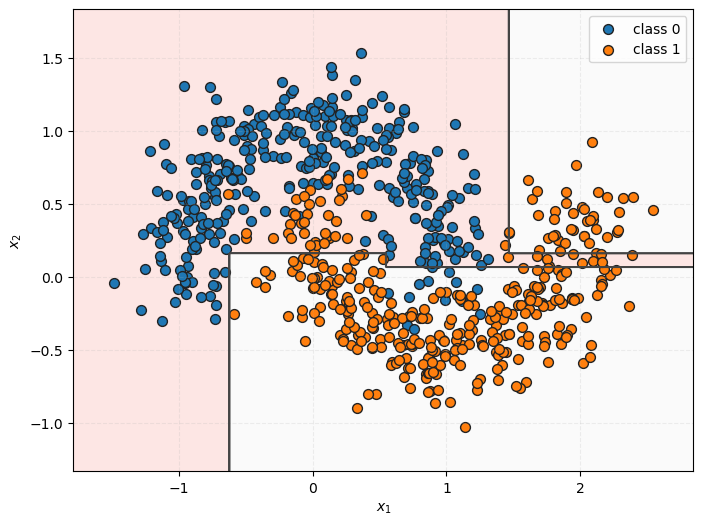

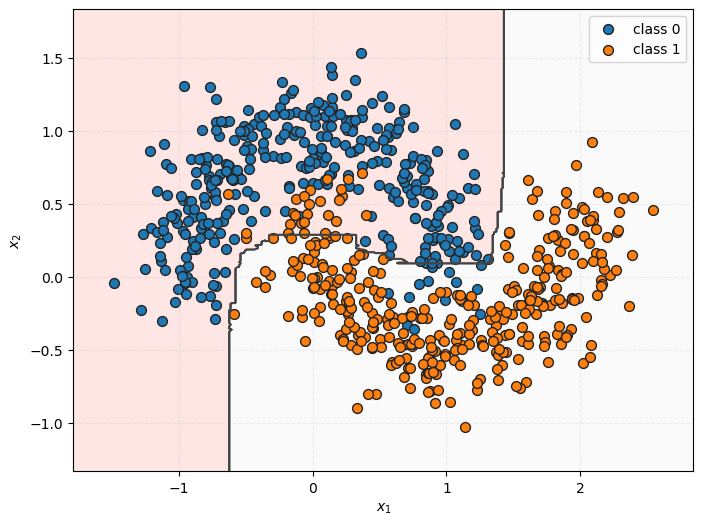

In [4]:
def plot_decision_boundary(clf, X, y, title=None):
    plt.figure(figsize=(8,6))
    x0_min, x0_max = X[:,0].min() - 0.3, X[:,0].max() + 0.3
    x1_min, x1_max = X[:,1].min() - 0.3, X[:,1].max() + 0.3
    xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 500),
                           np.linspace(x1_min, x1_max, 500))
    grid = np.c_[xx0.ravel(), xx1.ravel()]
    pred = clf.predict(grid).reshape(xx0.shape)

    plt.contourf(xx0, xx1, pred, alpha=0.32, cmap="Pastel1")
    plt.contour(xx0, xx1, pred, colors="#444444", linewidths=0.75)

    # 画出样本
    for label in np.unique(y):
        mask = (y == label)
        plt.scatter(X[mask,0], X[mask,1], s=50, edgecolors="#222222", label=f"class {label}")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2, linestyle="--")
    plt.show()

# 依次画出单个模型 + 投票集成
plot_decision_boundary(single_tree, X_train, y_train)
plot_decision_boundary(bag_clf, X_train, y_train)